In [4]:
import pandas as pd

DATA_DIR = './data' 

df_klines = pd.read_csv(f'{DATA_DIR}/BTCUSDT_4h_klines_with_factors.csv')
df_onchain = pd.read_csv(f'{DATA_DIR}/bitcoin_onchain_data_4h.csv')
df_sentiment = pd.read_csv(f'{DATA_DIR}/bitcoin_fear_greed_index_4h.csv')
df_derivatives = pd.read_csv(f'{DATA_DIR}/bitcoin_derivatives_comprehensive_4h.csv')

In [5]:
# Convert timestamps to UTC datetime
df_klines['timestamp'] = pd.to_datetime(df_klines['open_time'], format='mixed')

# For onchain, sentiment, derivatives: detect timestamp column
for df in [df_onchain, df_sentiment, df_derivatives]:
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    else:
        df['timestamp'] = pd.to_datetime(df[df.columns[0]], format='mixed')
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

## Klines

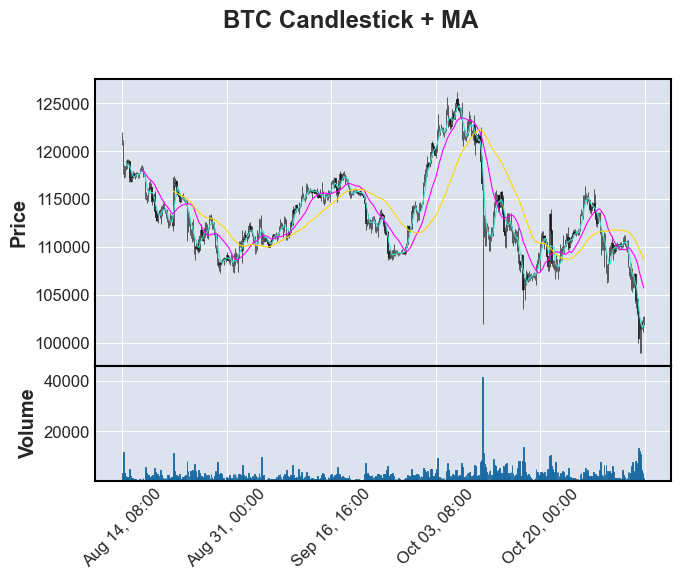

In [6]:
import matplotlib.pyplot as plt
import mplfinance as mpf

mpf.plot(df_klines.set_index('timestamp')[-500:], 
         type='candle', 
         mav=(5,20,50), 
         volume=True, 
         title="BTC Candlestick + MA")

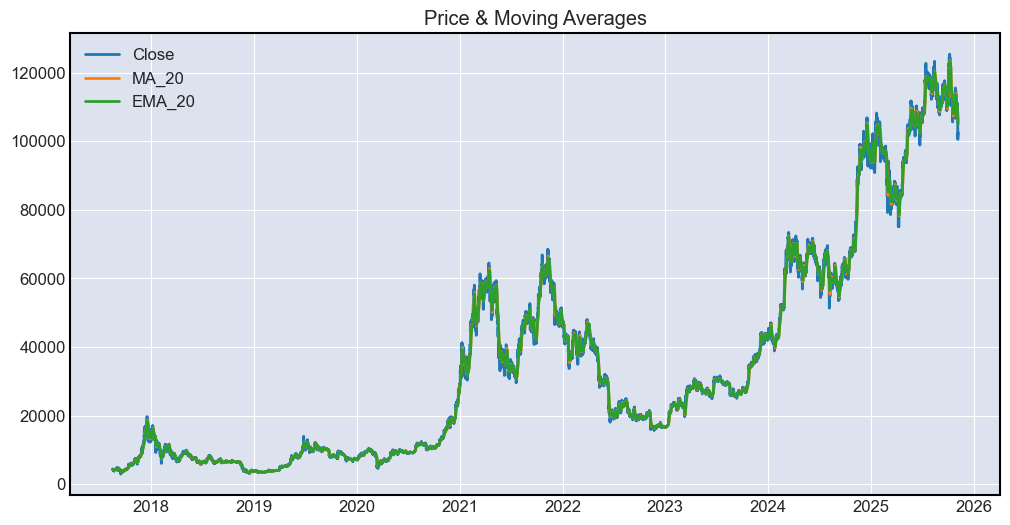

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df_klines['timestamp'], df_klines['close'], label='Close')
plt.plot(df_klines['timestamp'], df_klines['MA_20'], label='MA_20')
plt.plot(df_klines['timestamp'], df_klines['EMA_20'], label='EMA_20')
plt.legend()
plt.title("Price & Moving Averages")
plt.show()

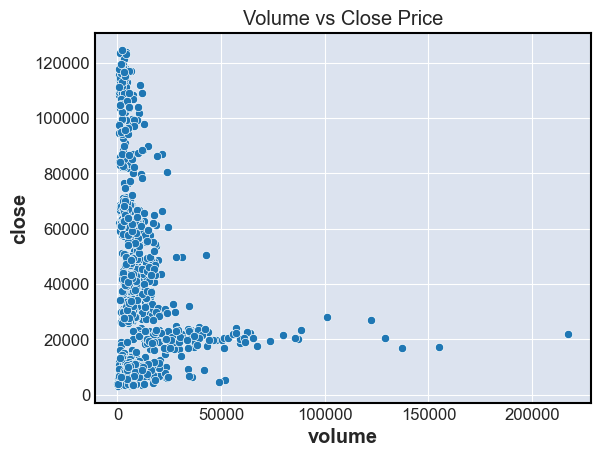

In [8]:
import seaborn as sns
sns.scatterplot(x='volume', y='close', data=df_klines.sample(1000))
plt.title("Volume vs Close Price")
plt.show()

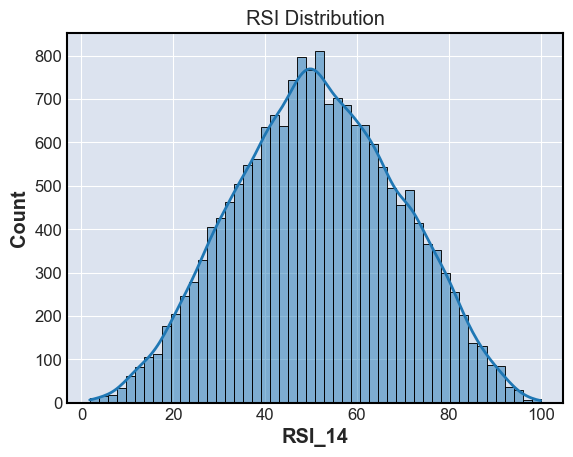

In [9]:
sns.histplot(df_klines['RSI_14'], bins=50, kde=True)
plt.title("RSI Distribution")
plt.show()

## Onchain

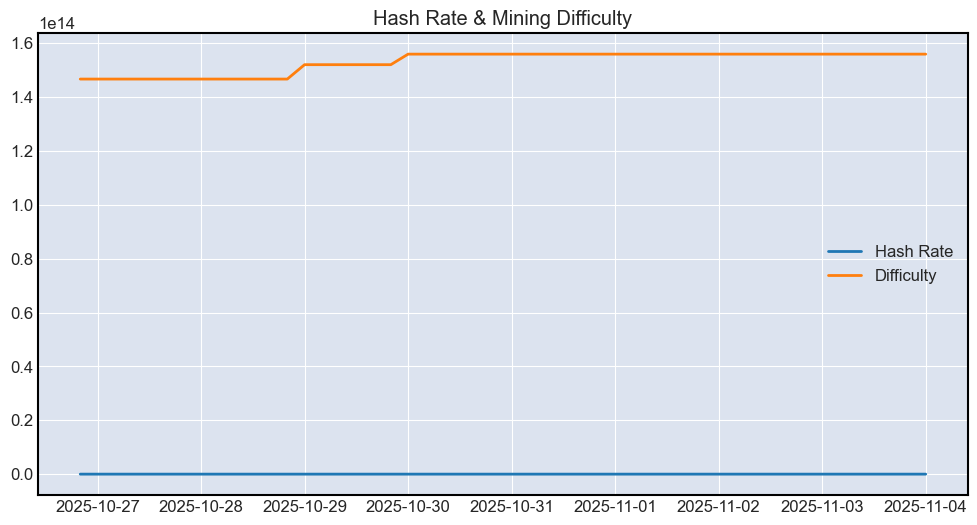

In [24]:
plt.figure(figsize=(12,6))
plt.plot(df_onchain['timestamp'], df_onchain['hash_rate'], label='Hash Rate')
plt.plot(df_onchain['timestamp'], df_onchain['mining_difficulty'], label='Difficulty')
plt.legend()
plt.title("Hash Rate & Mining Difficulty")
plt.show()

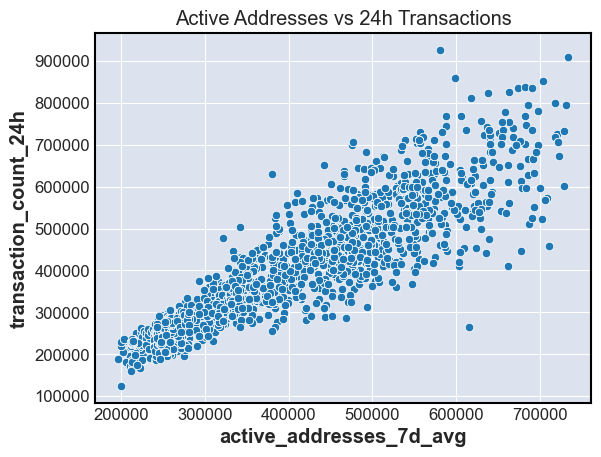

In [11]:
sns.scatterplot(x='active_addresses_7d_avg', y='transaction_count_24h', data=df_onchain)
plt.title("Active Addresses vs 24h Transactions")
plt.show()

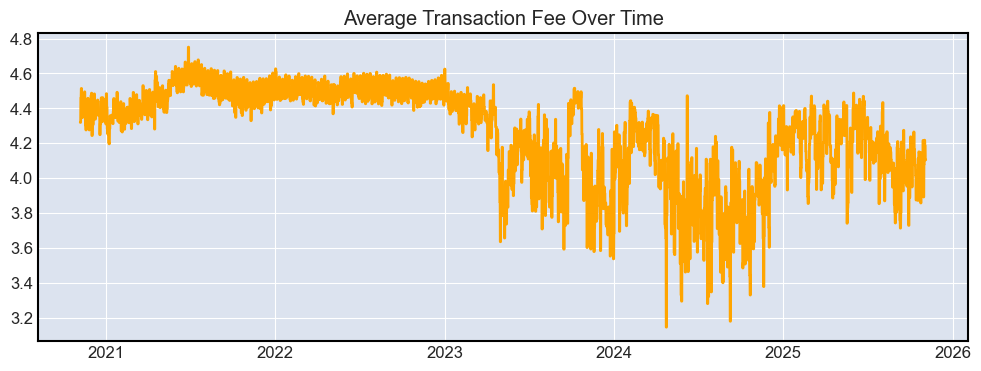

In [12]:
plt.figure(figsize=(12,4))
plt.plot(df_onchain['timestamp'], df_onchain['average_transaction_fee'], color='orange')
plt.title("Average Transaction Fee Over Time")
plt.show()

## Sentiment

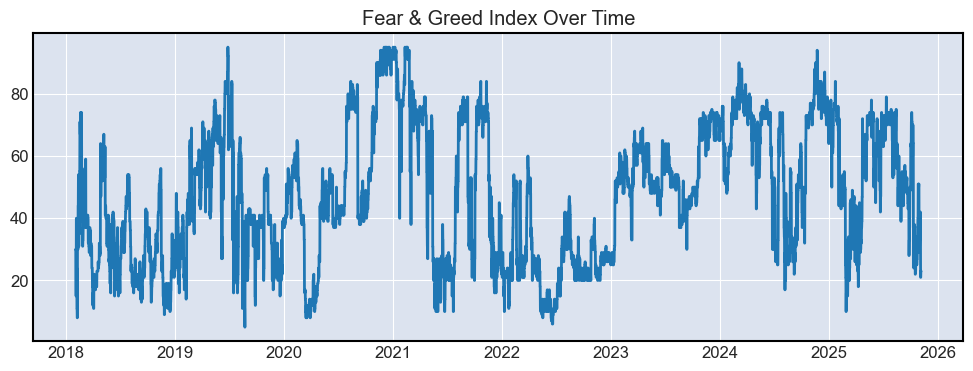

In [14]:
plt.figure(figsize=(12,4))
plt.plot(df_sentiment['timestamp'], df_sentiment['fear_greed_index'])
plt.title("Fear & Greed Index Over Time")
plt.show()

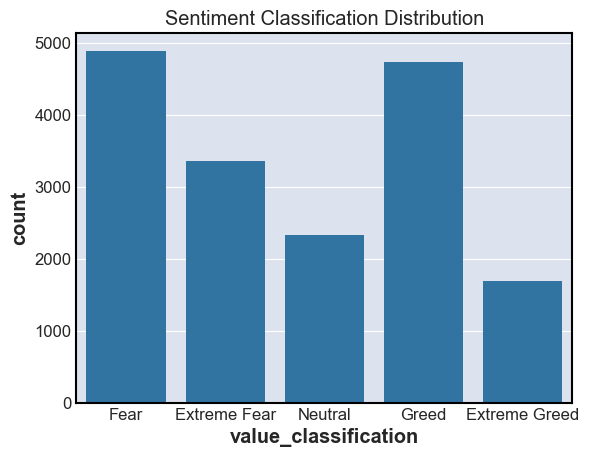

In [15]:
sns.countplot(x='value_classification', data=df_sentiment)
plt.title("Sentiment Classification Distribution")
plt.show()

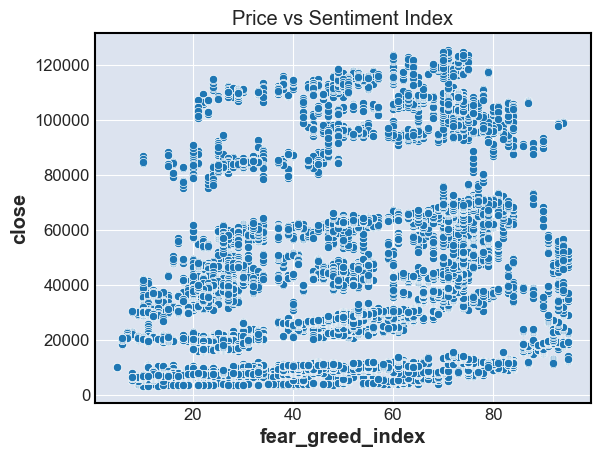

In [16]:
merged = df_klines[['timestamp','close']].merge(df_sentiment[['timestamp','fear_greed_index']], on='timestamp', how='inner')
sns.scatterplot(x='fear_greed_index', y='close', data=merged)
plt.title("Price vs Sentiment Index")
plt.show()

## Derivatives

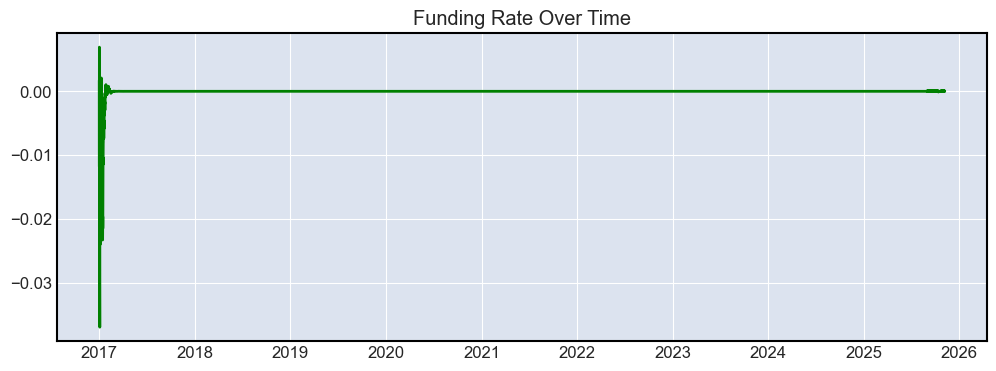

In [17]:
plt.figure(figsize=(12,4))
plt.plot(df_derivatives['timestamp'], df_derivatives['funding_rate_avg'], color='green')
plt.title("Funding Rate Over Time")
plt.show()

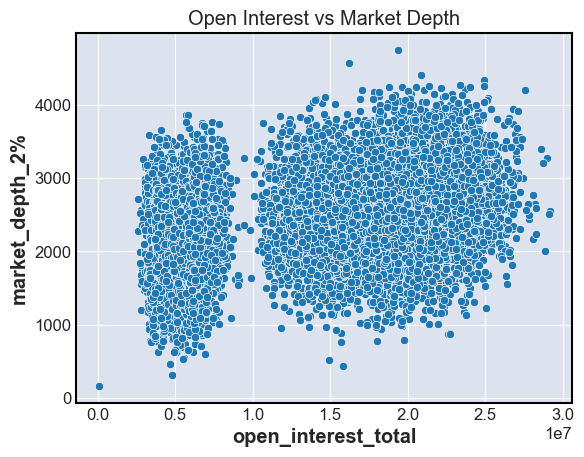

In [18]:
sns.scatterplot(x='open_interest_total', y='market_depth_2%', data=df_derivatives)
plt.title("Open Interest vs Market Depth")
plt.show()

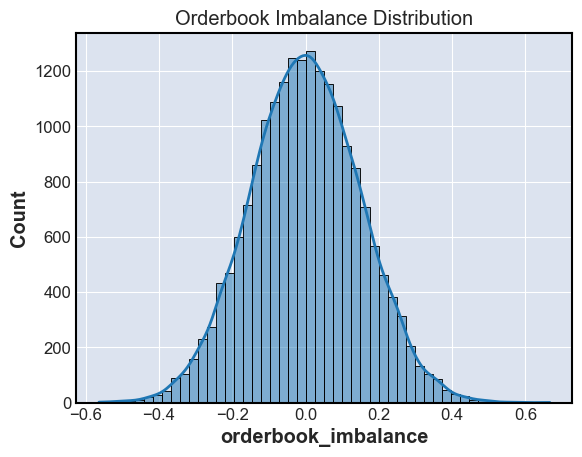

In [19]:
sns.histplot(df_derivatives['orderbook_imbalance'], bins=50, kde=True)
plt.title("Orderbook Imbalance Distribution")
plt.show()

## Combination

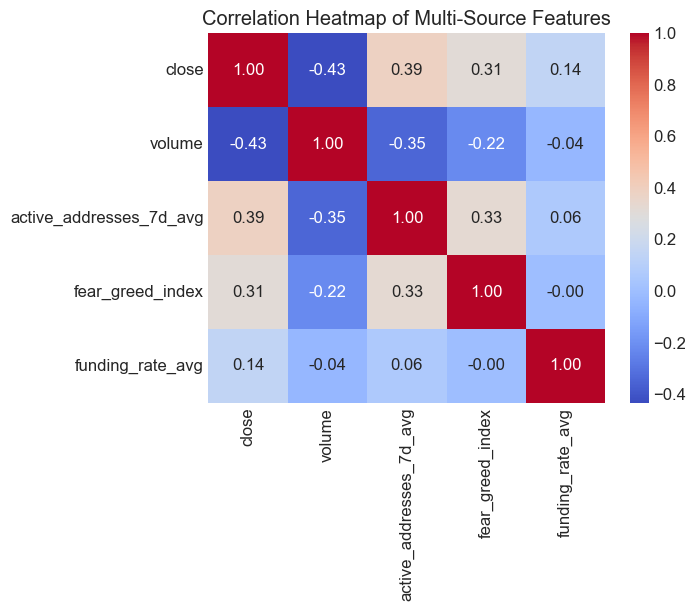

In [21]:
merged_all = df_klines[['timestamp','close','volume']].merge(
    df_onchain[['timestamp','active_addresses_7d_avg']], on='timestamp', how='inner'
).merge(
    df_sentiment[['timestamp','fear_greed_index']], on='timestamp', how='inner'
).merge(
    df_derivatives[['timestamp','funding_rate_avg']], on='timestamp', how='inner'
)

corr = merged_all.drop(columns='timestamp').corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Multi-Source Features")
plt.show()